# Module 2: Cyclic Graphs & Routing Loops

In this notebook, we will build a **Self-Correction (Generator-Critic) loop**.

Workflow:
1. **Writer Node**: Drafts a short technical paragraph explaining a programming topic.
2. **Critic Node**: Reviews the draft and provides criticism/issues.
3. **Router (Conditional Edge)**: Analyzes the state. If the Critic is satisfied OR we have looped 3 times, we route to `END`. Otherwise, we route back to the **Writer Node** with the feedback.

### Step 1: Initialize Chat Model Connection

In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(dotenv_path="../../../langchain/.env")

model = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    model="nvidia/nemotron-3-nano-30b-a3b:free",
    temperature=0.4,
)
print("Model client connected!")

Model client connected!


---
## 1. Defining the State Schema

We need to track the topic, the generated draft, the critic's feedback, and a counter tracking our cycles.

In [2]:
from typing import TypedDict

class ReflectionState(TypedDict):
    topic: str
    draft: str
    feedback: str
    revision_count: int

---
## 2. Defining nodes

In [3]:
from langchain_core.messages import SystemMessage, HumanMessage

def writer_node(state: ReflectionState) -> dict:
    """Node 1: Drafts or refines the technical explanation."""
    print("\n=== [Node: Writer] Generating Draft ===")
    topic = state.get("topic")
    draft = state.get("draft", "")
    feedback = state.get("feedback", "")
    
    # If feedback exists, ask the writer to revise
    if feedback:
        sys_prompt = "You are an technical writer revising a draft based on editor feedback. Re-write the draft to resolve the editor's concerns."
        user_prompt = f"Original Draft: {draft}\n\nEditor Feedback: {feedback}\n\nWrite the revised draft in exactly one paragraph:"
    else:
        sys_prompt = "You are a technical writer. Write a clear, concise one-paragraph explanation of the user's topic."
        user_prompt = f"Topic: {topic}"
        
    res = model.invoke([
        SystemMessage(content=sys_prompt),
        HumanMessage(content=user_prompt)
    ])
    
    # Return draft update
    return {"draft": res.content}


def critic_node(state: ReflectionState) -> dict:
    """Node 2: Evaluates the draft and writes feedback. Updates the revision count."""
    print("=== [Node: Critic] Evaluating Draft ===")
    draft = state.get("draft")
    count = state.get("revision_count", 0)
    
    sys_prompt = (
        "You are an editor. Check the user's technical paragraph. "
        "If it contains spelling/grammar errors, lacks clear explanations, or is longer than 4 sentences, "
        "respond with a list of feedback issues to address. "
        "If the paragraph is clear, accurate, and correct, respond with the exact word: 'APPROVED'."
    )
    
    res = model.invoke([
        SystemMessage(content=sys_prompt),
        HumanMessage(content=f"Draft: {draft}")
    ])
    
    # Return both the feedback text and increment the loop counter
    return {
        "feedback": res.content.strip(),
        "revision_count": count + 1
    }

---
## 3. Defining the Routing Function (Conditional Edge)

The router checks if the critic said 'APPROVED' or if we hit our maximum safety loop threshold of 3 iterations.

In [4]:
def should_continue_router(state: ReflectionState) -> str:
    """Evaluates state keys to choose the next node target."""
    feedback = state.get("feedback", "").upper()
    count = state.get("revision_count", 0)
    
    print(f"[Router Evaluator] Loop iteration: {count} | Editor status: {feedback[:20]}...")
    
    if "APPROVED" in feedback or count >= 3:
        print("-> Route decision: END (Finished or limit reached)")
        return "end"
    else:
        print("-> Route decision: REVISE (Back to Writer)")
        return "revise"

---
## 4. Assembling the Cyclic Graph

In [5]:
from langgraph.graph import START, END, StateGraph

builder = StateGraph(ReflectionState)

# Add nodes
builder.add_node("writer", writer_node)
builder.add_node("critic", critic_node)

# Set entry point
builder.add_edge(START, "writer")

# Normal connection
builder.add_edge("writer", "critic")

# Conditional connection looping back or ending
builder.add_conditional_edges(
    "critic",
    should_continue_router,
    {
        "revise": "writer",
        "end": END
    }
)

graph = builder.compile()
print("Cyclic state graph compiled!")

Cyclic state graph compiled!


### Visualizing the loop structure

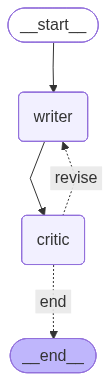

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().print_ascii())

---
## 5. Streaming Execution Loops

Let's execute the graph. We will feed in a topic and watch it loop back and forth in real-time.

In [7]:
inputs = {
    "topic": "how recursion works in programming",
    "revision_count": 0
}

for event in graph.stream(inputs):
    # Print the state update from the active node
    for node_name, state_update in event.items():
        print(f"[State update from node '{node_name}']:")
        for key, val in state_update.items():
            # Truncate content previews
            val_preview = str(val)[:150] + "..." if len(str(val)) > 150 else val
            print(f"  {key}: {val_preview}")
    print("-" * 60)


=== [Node: Writer] Generating Draft ===
[State update from node 'writer']:
  draft: Recursionis a programming technique where a function calls itself to solve a problem by breaking it down into smaller, identical sub‑problems until it...
------------------------------------------------------------
=== [Node: Critic] Evaluating Draft ===
[Router Evaluator] Loop iteration: 1 | Editor status: APPROVED...
-> Route decision: END (Finished or limit reached)
[State update from node 'critic']:
  feedback: APPROVED
  revision_count: 1
------------------------------------------------------------


---
## 6. Testing Infinite Loop Protection (Recursion Limits)

Let's see what happens if we set `recursion_limit` to a small value (e.g. 2). Since going Start -> Writer -> Critic requires 3 transitions, a recursion limit of 2 will trigger a halt.

In [8]:
from langgraph.errors import GraphRecursionError

inputs = {
    "topic": "APIs",
    "revision_count": 0
}

print("Executing graph with a strict recursion limit of 2...")
try:
    graph.invoke(inputs, config={"recursion_limit": 2})
except GraphRecursionError as e:
    print("\n[RECURSION ERROR CAUGHT SUCCESSFULLY]")
    print("Error details:", e)

Executing graph with a strict recursion limit of 2...

=== [Node: Writer] Generating Draft ===
=== [Node: Critic] Evaluating Draft ===
[Router Evaluator] Loop iteration: 1 | Editor status: - MISSING SPACE IN “...
-> Route decision: REVISE (Back to Writer)

[RECURSION ERROR CAUGHT SUCCESSFULLY]
Error details: Recursion limit of 2 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT
